In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
from scipy.optimize import curve_fit
from numpy import random

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path1 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-38-47.csv'
path2 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-39-38.csv'
path3 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-40-12.csv'
path4 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-41-11.csv'
path5 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-42-15.csv'
path6 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-42-57.csv'
path7 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-44-05.csv'
path8 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-44-45.csv'
path9 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-45-21.csv'
path10 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-46-09.csv'

In [4]:
# load data for high 50cm transect with 10 trials, using predefined path variables
L1 = pd.read_csv(path1)
L2 = pd.read_csv(path2)
L3 = pd.read_csv(path3)
L4 = pd.read_csv(path4)
L5 = pd.read_csv(path5)
L6 = pd.read_csv(path6)
L7 = pd.read_csv(path7)
L8 = pd.read_csv(path8)
L9 = pd.read_csv(path9)
L10 = pd.read_csv(path10)

alldata = [L1, L2, L3, L4, L5,  L6, L7, L8, L9, L10]

## Distance calibration: Assuming total transects are of equal length

In [5]:
# assume all transects go from 0m to 0.8m
# convert time column in data to distance column
for n in range(len(alldata)):
    time_list = alldata[n]["time"].tolist()
    get_distance = []
    for i in range(len(time_list)):
        seconds_since_midnight = time_list[i]
        if i==0:
            first_time = seconds_since_midnight
        distance = (seconds_since_midnight-first_time) / (len(time_list) * 0.1) * 8 # convert to m, largest t is 0.8 m
        get_distance.append(distance)

    alldata[n]['time'] = get_distance
    alldata[n] = alldata[n].rename(columns={"time":"distance"})

In [6]:
# turn the data into a 2D grid to visualize changes in Bz along the dike

datagrid = []
for i in range(len(alldata)):
    # Original data points (x and y)
    index = i
    column = "Bz" # Looking at the z-component!
    transect_length = list(alldata[index]["distance"])[-1]
    x_original = list(alldata[index]["distance"])
    y_original = list(alldata[index][column])

    # New 1D grid
    x_new = np.linspace(0, transect_length, 100)

    # Use numpy.interp() to interpolate values onto the new grid
    y_interpolated = np.interp(x_new, x_original, y_original)

    # list of lists where every row is a transect
    datagrid.append(y_interpolated)
datagrid = np.array(datagrid)
# now it's an ndarray with each column being a transect
datagrid = datagrid.transpose()


# x coordinates for all the data points
one_row_xs = [0.2*x for x in range(0,len(datagrid[0]))]
all_xs = np.array([one_row_xs for x in range(0,len(datagrid))]).ravel()
# y coordinates for all the data points
distances_array = np.array(get_distance)
all_ys = np.tile(np.array([x_new]).transpose(), (1, len(datagrid[0]))).ravel()
# flatten the Bz_ndarray array:
Bz_flattened = datagrid.ravel()
# make sure everything is sized  correctly
print([len(x) for x in [all_xs, all_ys, Bz_flattened]])

# Create a grid on which to interpolate
xi, yi = np.meshgrid(np.linspace(0, one_row_xs[-1], 100), distances_array)

# Interpolate values at grid points using griddata
zi = griddata((all_xs, all_ys), Bz_flattened, (xi, yi), method='cubic')  # 'cubic' or 'linear' interpolation

[1000, 1000, 1000]


/tmp/ipython-input-184250625.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(xi, yi, zi, cmap='viridis', levels=50, alpha=0.75, label='Interpolated Data')


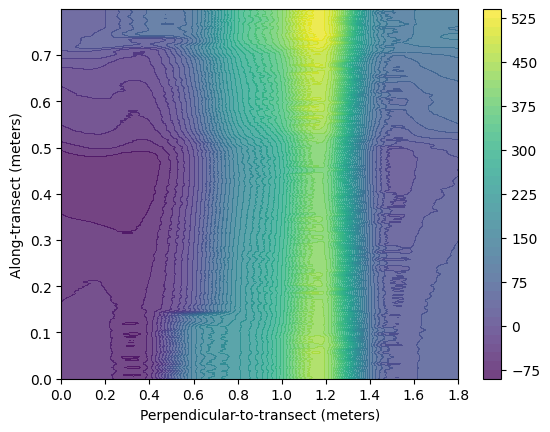

In [7]:
# Plot the interpolated grid
plt.contourf(xi, yi, zi, cmap='viridis', levels=50, alpha=0.75, label='Interpolated Data')

plt.xlabel('Perpendicular-to-transect (meters)')
plt.ylabel('Along-transect (meters)')
#plt.legend()
plt.colorbar()

plt.show()

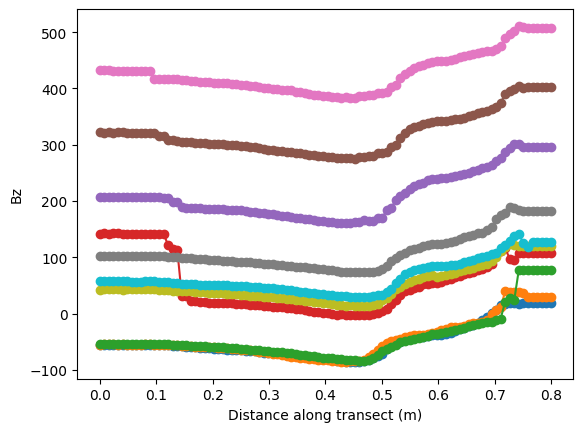

In [8]:
for i in range(datagrid.shape[1]):   # datagrid is (100, 10) if you have 10 transects
    plt.plot(x_new, datagrid[:,i], marker='o', linestyle='-', label=f'Transect {i+1}')
plt.xlabel("Distance along transect (m)")
plt.ylabel("Bz")
#plt.legend()
plt.show()

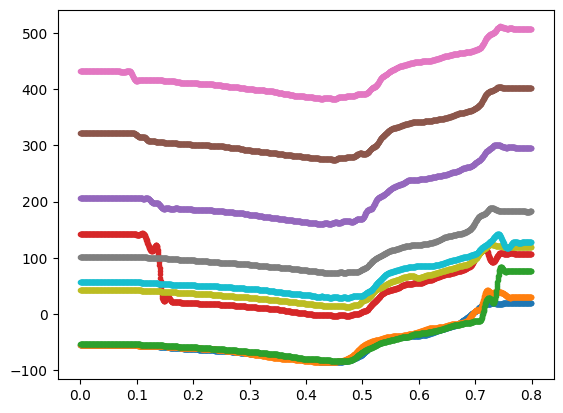

In [9]:
#PRINT REAL DATA

# Suppose you had N real transects
N = len(alldata)
grid_columns = zi.shape[1]
# Map which columns correspond to the original data
transect_col_indices = np.linspace(0, grid_columns-1, N).astype(int)

# Plot those
for i, col in enumerate(transect_col_indices):
    plt.plot(yi[:,col], zi[:,col], marker='.', linestyle='-', label=f'Real Transect {i+1}')

0
11
22
33
44
55
66
77
88
99


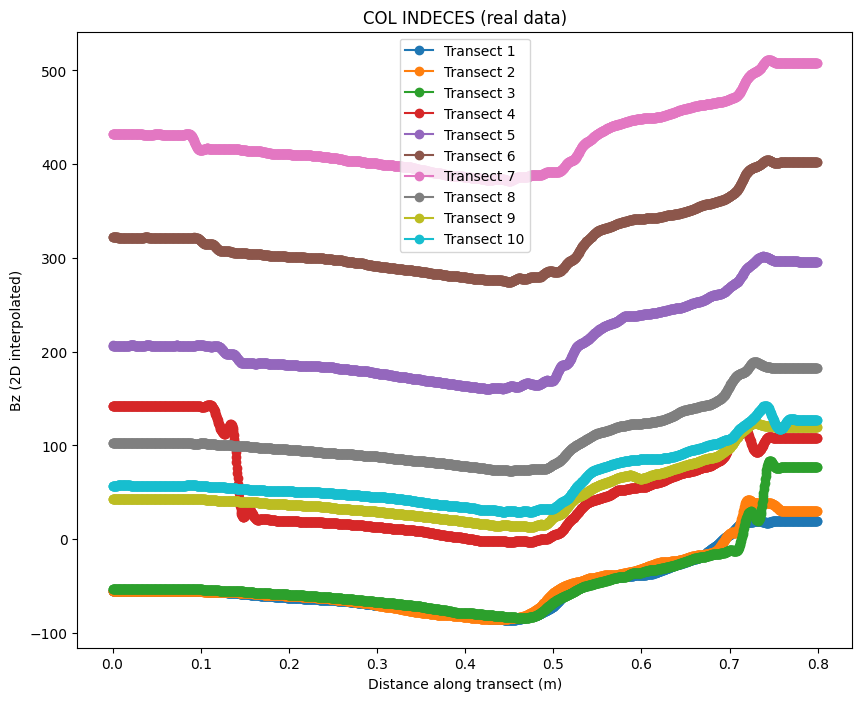

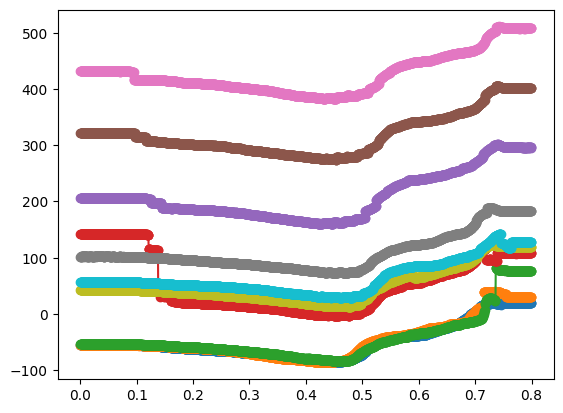

In [10]:
#PLOT TRANSECTS

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,8))

num_transects = 10
grid_columns = zi.shape[1]

# Select column indices corresponding to the approximate locations of your physical transects
col_indices = np.linspace(0, grid_columns-1, num_transects).astype(int)

for i, col in enumerate(col_indices):
    plt.plot(yi[:,col], zi[:,col], marker='o', linestyle='-', label=f'Transect {i+1}')
    print(col)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Bz (2D interpolated)")
plt.legend()
plt.title("COL INDECES (real data)")
plt.show()

for n in range(len(alldata)):
    plt.plot(alldata[n]["distance"], alldata[n]["Bz"], marker='o', linestyle='-', label=f'Raw Transect {n+1}')

0
10
20
30
40
50
60
70
80
90


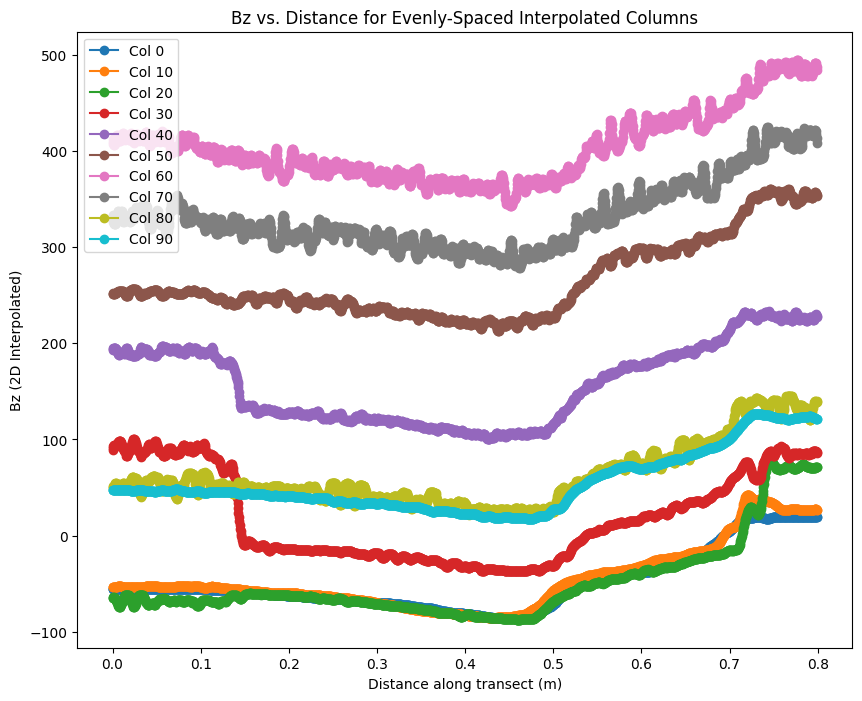

In [11]:
#PLOT INTERPOLATED

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,8))

# How many columns in your interpolated grid?
num_cols = zi.shape[1]

# Choose your column step for 10 profiles (or as close as possible)
step = num_cols // 10  # integer division

# Make a list of column indices: 0, step, 2*step, ..., up to (but less than) num_cols
col_indices = [i*step for i in range(10)]

for i, col in enumerate(col_indices):
    plt.plot(yi[:,col], zi[:,col], marker='o', linestyle='-', label=f'Col {col}')
    print(col)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Bz (2D Interpolated)")
plt.legend()
plt.title("Bz vs. Distance for Evenly-Spaced Interpolated Columns")
plt.show()

0
10
20
30
40
50
60
70
80
90


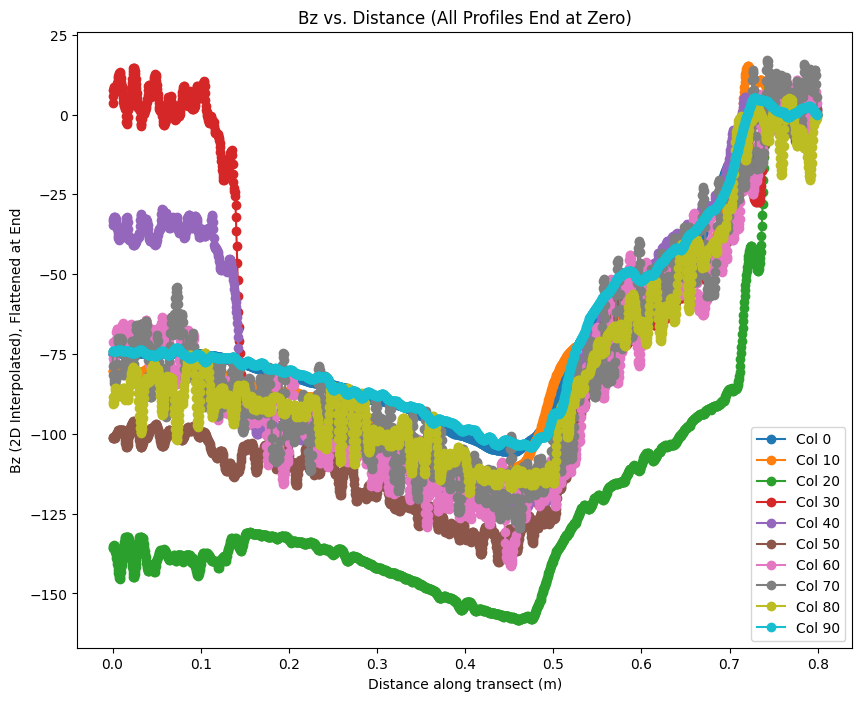

In [12]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np

# Make a copy of zi to preserve the original
zi2 = zi.copy()

# Zero each column so that its last value is zero
for col in range(zi2.shape[1]):
    zi2[:, col] = zi2[:, col] - zi2[-1, col]  # subtract the last value in each column

# zi2 now contains all zeroed profiles

plt.figure(figsize=(10,8))

num_cols = zi.shape[1]
step = num_cols // 10
col_indices = [i*step for i in range(10)]

for i, col in enumerate(col_indices):
    profile = zi[:,col]
    zeroed_profile = profile - profile[-1]    # shift so last value is zero
    plt.plot(yi[:,col], zeroed_profile, marker='o', linestyle='-', label=f'Col {col}')
    print(col)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Bz (2D Interpolated), Flattened at End")
plt.legend()
plt.title("Bz vs. Distance (All Profiles End at Zero)")
plt.show()

0
10
20
30
40
50
60
70
80
90


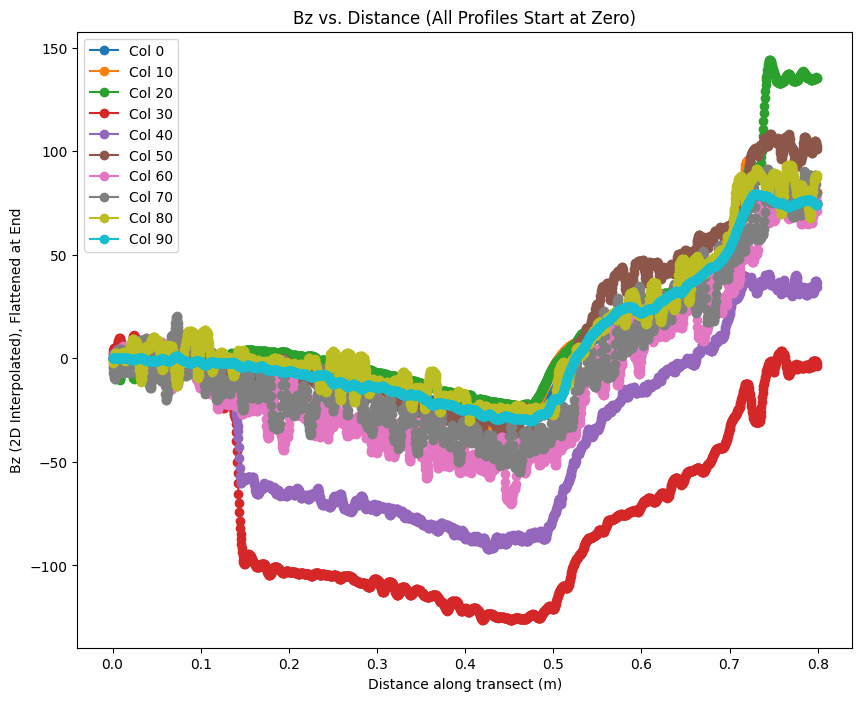

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,8))

num_cols = zi.shape[1]
step = num_cols // 10
col_indices = [i*step for i in range(10)]

for i, col in enumerate(col_indices):
    profile = zi[:,col]
    zeroed_profile = profile - profile[0]    # shift so last value is zero
    plt.plot(yi[:,col], zeroed_profile, marker='o', linestyle='-', label=f'Col {col}')
    print(col)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Bz (2D Interpolated), Flattened at End")
plt.legend()
plt.title("Bz vs. Distance (All Profiles Start at Zero)")
plt.show()

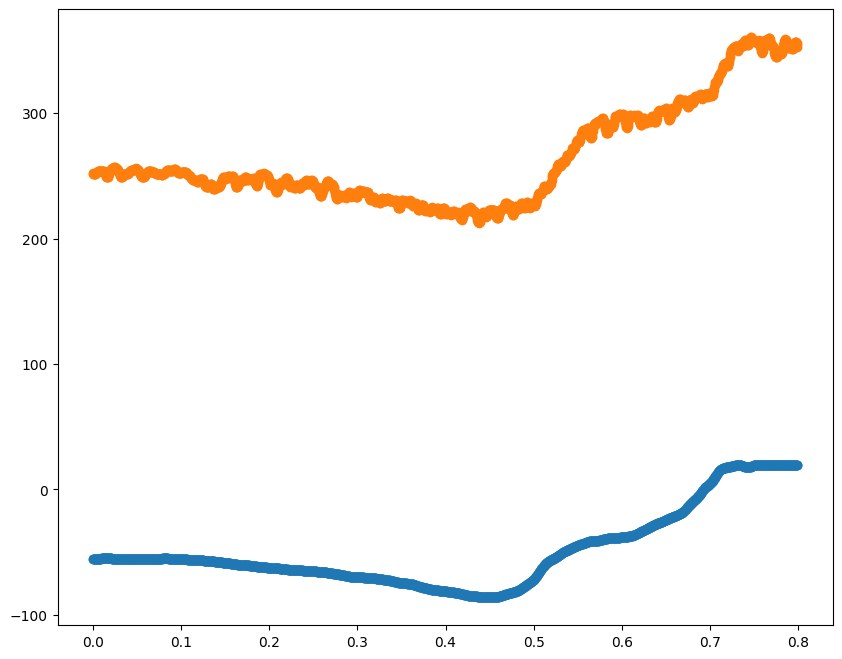

In [14]:
# plot Bz vs. distance along transect for transects with only 2 (valid) trials
plt.figure(figsize=(10,8))
plt.plot(yi[:,0], zi[:,0], marker='o', linestyle='-')
plt.plot(yi[:,50], zi[:,50], marker='o', linestyle='-')

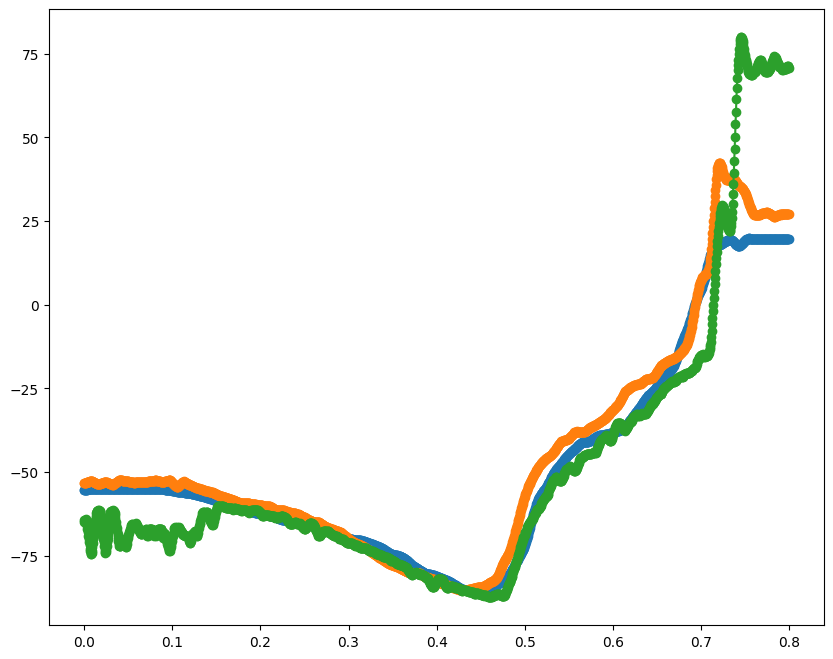

In [15]:
# plot Bz vs. distance along transect for high 50cm transect with 10 trials
plt.figure(figsize=(10,8))
plt.plot(yi[:,0], zi[:,0], marker='o', linestyle='-')
plt.plot(yi[:,10], zi[:,10], marker='o', linestyle='-')
plt.plot(yi[:,20], zi[:,20], marker='o', linestyle='-')
#plt.plot(yi[:,30], zi[:,30], marker='o', linestyle='-')
#plt.plot(yi[:,40], zi[:,40], marker='o', linestyle='-')
#plt.plot(yi[:,50], zi[:,50], marker='o', linestyle='-')
#plt.plot(yi[:,60], zi[:,60], marker='o', linestyle='-')
#plt.plot(yi[:,70], zi[:,70], marker='o', linestyle='-')
#plt.plot(yi[:,80], zi[:,80], marker='o', linestyle='-')
#plt.plot(yi[:,90], zi[:,90], marker='o', linestyle='-')

[ 642.16225633 -464.15503799  149.31589927]


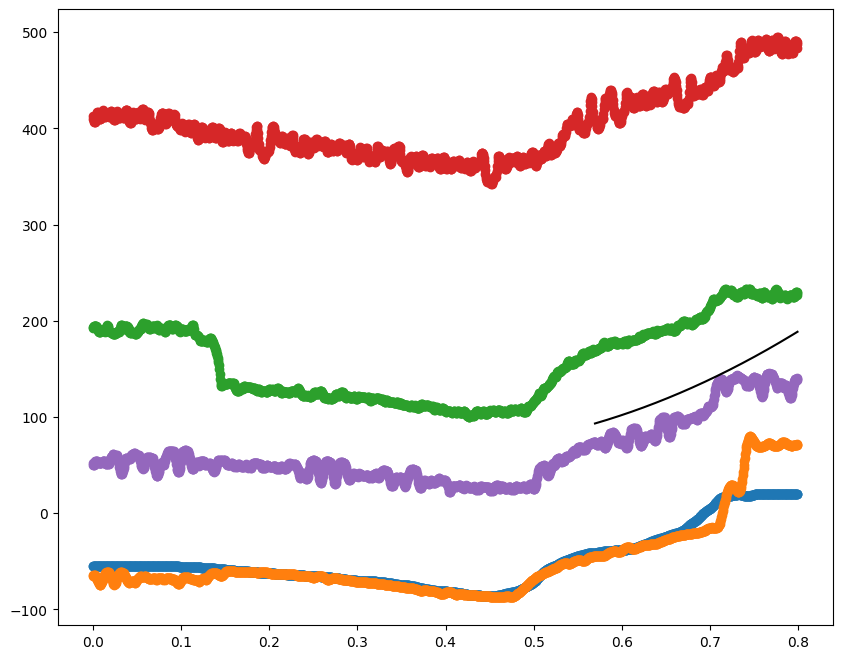

In [16]:
# quadratically fit the "smooth" piece of the data near the end (all data points after 1200th point)
# we're going to use this end piece to estimate the measurement noise on the whole curve

lower_index = 1200

y_list = list(yi[lower_index:,0])*4
z_list = list(zi[lower_index:,0]) + list(zi[lower_index:,25]) + list(zi[lower_index:,50]) + list(zi[lower_index:,75])

def quadratic_function(x, a, b, c):
    return (a*x**2 + b*x + c)

params, cov = curve_fit(quadratic_function, y_list, z_list, p0 = [0,0,0], maxfev=10000)
print(params)

plt.figure(figsize=(10,8))
plt.plot(yi[:,0], zi[:,0], marker='o', linestyle='-')
plt.plot(yi[:,20], zi[:,20], marker='o', linestyle='-')
plt.plot(yi[:,40], zi[:,40], marker='o', linestyle='-')
plt.plot(yi[:,60], zi[:,60], marker='o', linestyle='-')
plt.plot(yi[:,80], zi[:,80], marker='o', linestyle='-')
plt.plot(yi[lower_index:,0], quadratic_function(yi[lower_index:,0], *params), 'k-', label='Fit')


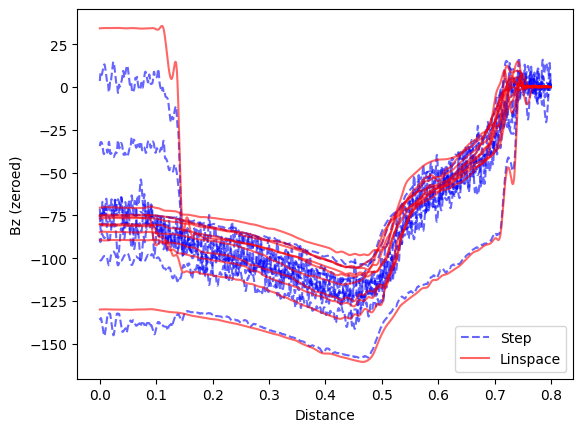

In [17]:
col_indices_step = [i*step for i in range(10)]
col_indices_lin = np.linspace(0, num_cols-1, 10).astype(int)

plt.figure()

for col in col_indices_step:
    plt.plot(yi[:,col], zi2[:,col], 'b--', alpha=0.6, label='Step' if col==col_indices_step[0] else "")

for col in col_indices_lin:
    plt.plot(yi[:,col], zi2[:,col], 'r-', alpha=0.6, label='Linspace' if col==col_indices_lin[0] else "")

plt.xlabel('Distance')
plt.ylabel('Bz (zeroed)')
plt.legend()
plt.show()

Quadratic fit params: [-133.08831164  502.03068229 -306.83188344]


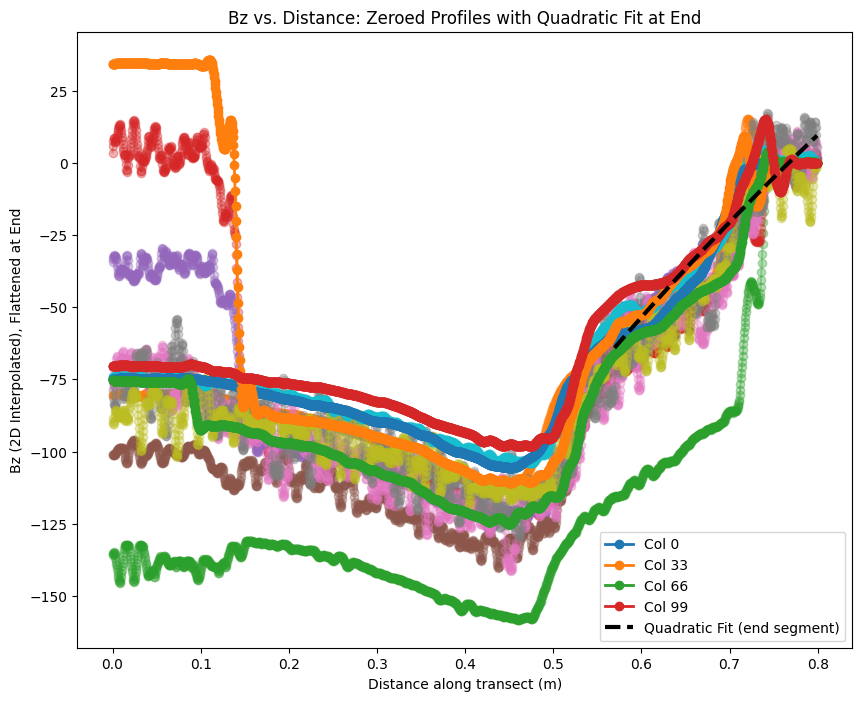

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Step 1: Zero ("normalize") each profile so the last value is zero ----
zi2 = zi.copy()
for col in range(zi2.shape[1]):
    zi2[:, col] -= zi2[-1, col]

# ---- Step 2: Collect the end regions for fitting (after lower_index) ----
lower_index = 1200

# Let's use several evenly spaced profiles for good statistics
num_cols = zi2.shape[1]
n_profiles_to_use = 4
indices_to_fit = np.linspace(0, num_cols - 1, n_profiles_to_use, dtype=int)

y_list = []
z_list = []
for idx in indices_to_fit:
    y_end = yi[lower_index:, idx]
    z_end = zi2[lower_index:, idx]
    y_list.extend(y_end)
    z_list.extend(z_end)

y_list = np.array(y_list)
z_list = np.array(z_list)

# ---- Step 3: Quadratic fit function and fitting ----
def quadratic_function(x, a, b, c):
    return (a * x ** 2 + b * x + c)

params, cov = curve_fit(quadratic_function, y_list, z_list, p0 = [0,0,0], maxfev=10000)
print("Quadratic fit params:", params)

# ---- Step 4: Plot all (zeroed) profiles and overlay the quadratic fit at the end region ----
plt.figure(figsize=(10,8))

# Plot all zeroed profiles (every Nth to avoid clutter)
N_skip = max(1, num_cols // 10)
for col in range(0, num_cols, N_skip):
    plt.plot(yi[:, col], zi2[:, col], 'o-', alpha=0.35)

# Overlay just the profiles used for the fit with thicker lines
for idx in indices_to_fit:
    plt.plot(yi[:, idx], zi2[:, idx], 'o-', linewidth=2, label=f'Col {idx}')

# Overlay the quadratic fit over the END region of one of the fitting profiles
y_fit = yi[lower_index:, indices_to_fit[0]]
z_fit = quadratic_function(y_fit, *params)
plt.plot(y_fit, z_fit, 'k--', linewidth=3, label='Quadratic Fit (end segment)')

plt.xlabel("Distance along transect (m)")
plt.ylabel("Bz (2D Interpolated), Flattened at End")
plt.legend(loc='best')
plt.title("Bz vs. Distance: Zeroed Profiles with Quadratic Fit at End")
plt.show()

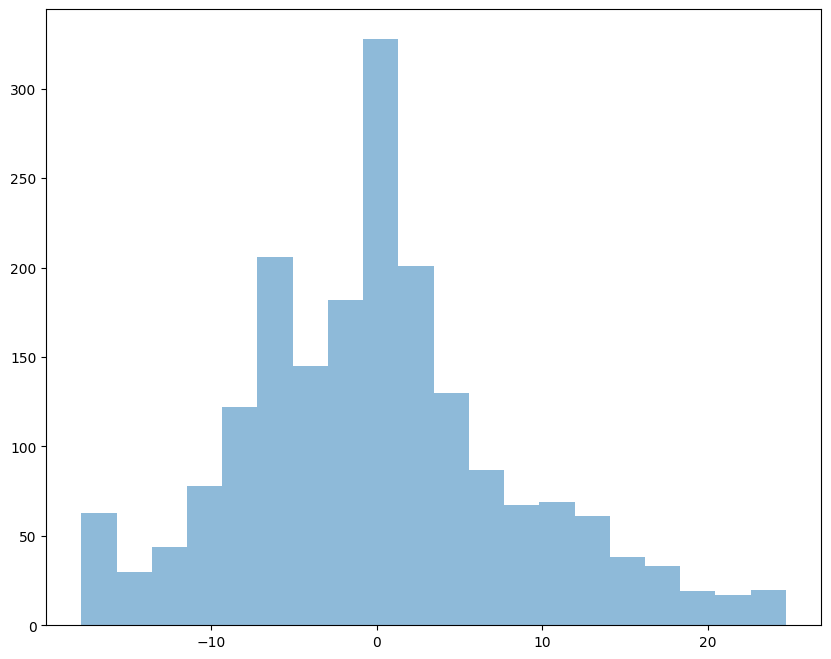

In [19]:
# plot the histogram of the residuals
# residuals are the difference in y-values between the data points and the quadratic model we just got
# residuals help characterize the random measurement noise
residuals = np.array(z_list)-quadratic_function(np.array(y_list), *params)

plt.figure(figsize=(10,8))
plt.hist(residuals, 20,alpha=0.5)
plt.show()

In [20]:
# accounting for autocorrelation

# size of each chunk
n = int(len(residuals)/4)

# partition the list using list comprehension
partitioned_means = [np.mean(residuals[i:i + n]) for i in range(0, len(residuals), n)]
std_of_offset = np.std(partitioned_means)

[1685, 1685]
[ 2.20526914e-01  4.12253651e-02  3.11649521e-01 -7.78486256e+01
  1.86047540e+01]


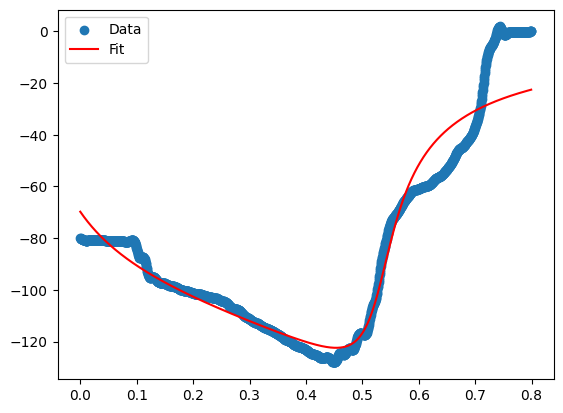

In [31]:
# set initial guesses for W and Z
WWtemp = 0.17 # this is the width of the dike (meters)
ZZtemp = 0.03 # this is the height of the phone above the dike (meters)
# can tweak if needed!

# this is the long equation for Bz given in the instructions
def Bz_function(x, dx, ZZ, WW, phi, JJ):
    term1 = np.cos(phi * np.pi / 180) * \
    np.log( ( (-WW + x - dx)**2 + ZZ**2 ) / ( (WW + x - dx)**2 + ZZ**2 ) )
    term2 = -np.sin(phi * np.pi / 180) * np.arctan( (x - dx - WW) /ZZ )
    term3 = np.sin(phi * np.pi / 180) * np.arctan( (x - dx + WW) /ZZ )
    return 2 * JJ * (term1 + term2 + term3)

# pick a single profile to check (the one at the 70th row)
profile_index = 55

yset = np.array(yi)[:,profile_index]
bset = np.array(zi2)[:,profile_index]-np.array(zi2)[-1,profile_index]
print([len(yset),len(bset)])

# do a non-linear fit of the single profile using the given equation
# save the parameters that correspond with the best fit
params, cov = curve_fit(Bz_function, yset, bset, p0 = [-WWtemp, ZZtemp, WWtemp, 75, 10], maxfev=10000)
print(params)

plt.scatter(yset, bset, label='Data')
plt.plot(yset, Bz_function(yset, *params), 'r-', label='Fit')
plt.legend()
plt.show()

Original data points: 1685
Data points used for fit: 1685
[  0.90788924   0.11689311  -0.43588088 -26.2846057   18.77548074]


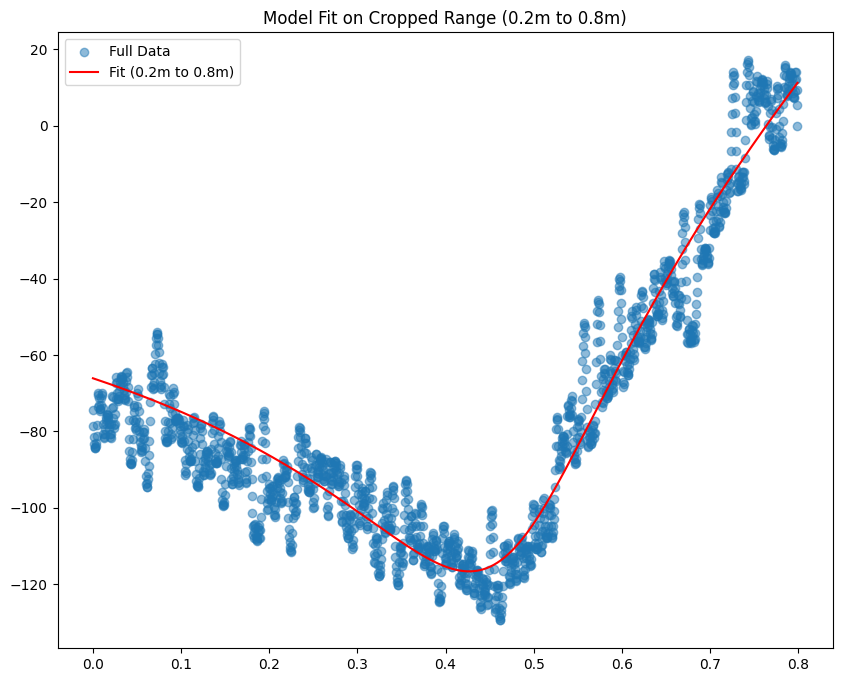

In [ ]:
# Do the same model fit process as above but crop the data to only 0.2m to 0.8m

#Tweak initial guesses for parameters if needed
WWtemp = 0.17
ZZtemp = 0.01


def Bz_function(x, dx, ZZ, WW, phi, JJ):
    term1 = np.cos(phi * np.pi / 180) * \
    np.log( ( (-WW + x - dx)**2 + ZZ**2 ) / ( (WW + x - dx)**2 + ZZ**2 ) )
    term2 = -np.sin(phi * np.pi / 180) * np.arctan( (x - dx - WW) /ZZ )
    term3 = np.sin(phi * np.pi / 180) * np.arctan( (x - dx + WW) /ZZ )
    return 2 * JJ * (term1 + term2 + term3)


profile_index = 70

# Original full profile data (extracted from interpolation grid)
yset = np.array(yi)[:,profile_index]
bset = np.array(zi2)[:,profile_index]-np.array(zi2)[-1,profile_index]

# --- MODIFICATION: CROP THE DATA FOR FITTING ---
CROP_START_Y = 0.2
CROP_END_Y = 0.8

# 1. Create a boolean mask where the distance (yset) is within the desired range
fit_mask = (yset >= CROP_START_Y) & (yset <= CROP_END_Y)

# 2. Apply the mask to both the distance (yset) and field (bset) data
yset_fit = yset[fit_mask]
bset_fit = bset[fit_mask]

print(f"Original data points: {len(yset)}")
print(f"Data points used for fit: {len(yset)}")

# --- Perform the fit using the CROPPED data ---
# Pass the cropped arrays (yset_fit, bset_fit) to curve_fit
params, cov = curve_fit(Bz_function, yset_fit, bset_fit,
                        p0 = [-WWtemp, ZZtemp, WWtemp, 75, 10], maxfev=10000)
print(params)

# --- Plotting ---
plt.figure(figsize=(10,8))
# Plot ALL original data (light color)
plt.scatter(yset, bset, label='Full Data', alpha=0.5)
# Plot the fit line across the entire original distance range (yset_full)
# This shows how the fit (learned from the cropped data) behaves across the full profile.
plt.plot(yset, Bz_function(yset, *params), 'r-', label='Fit (0.2m to 0.8m)')
plt.legend()
plt.title(f'Model Fit on Cropped Range ({CROP_START_Y}m to {CROP_END_Y}m)')
plt.show()

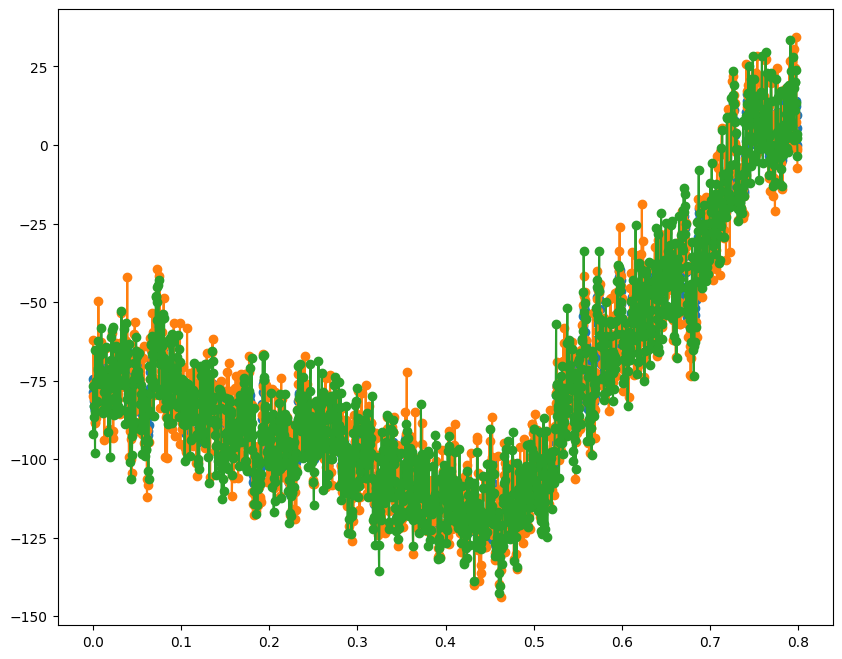

In [ ]:
# visually show residuals
plt.figure(figsize=(10,8))
plt.plot(yset, bset, marker='o', linestyle='-')
random_errors = np.random.choice(residuals, size=len(bset), replace=True, p=None)
plt.plot(yset, bset+random_errors, marker='o', linestyle='-')
random_errors = np.random.choice(residuals, size=len(bset), replace=True, p=None)
plt.plot(yset, bset+random_errors, marker='o', linestyle='-')

In [ ]:
# use bootstrap to find uncertainty on parameters
NN = 1000

all_params = []
for i in range(NN):
    random_errors = np.random.choice(residuals, size=len(bset), replace=True, p=None) #uncorrelated/random error
    #random_errors = np.array(list(random.normal(loc=0.0, scale=std_of_offset, size=1))*len(bset)) #correlated/systematic error
    pseudo_bset = bset + random_errors #add the resampled "simulated" error to the original data
    params, cov = curve_fit(Bz_function, yset, pseudo_bset, \
                            p0 = params, maxfev=10000) # fit the new dataset to the Bz model equation
    # changed p0 to params so that the starting parameter guess is the parameters found for the best-fit curve
    all_params.append(params)

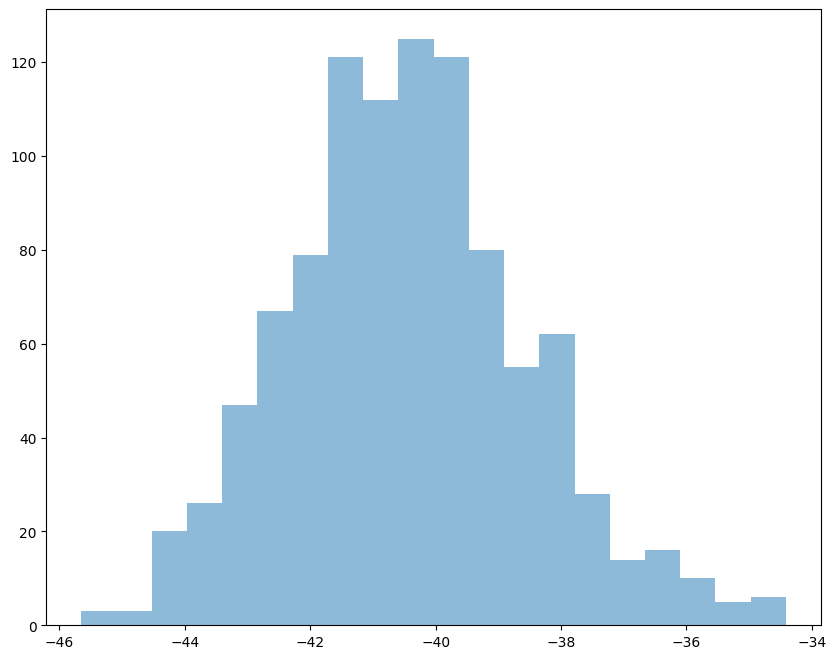

lower 95% CI, mean, higher 95% CI


[np.float64(-43.967169259095094),
 np.float64(-40.44366136939626),
 np.float64(-36.27785752468641)]

In [ ]:
# show histogram of best-fit phi value found in each resampling trial
resampled_phis = np.array(all_params)[:,3]

plt.figure(figsize=(10,8))
plt.hist(resampled_phis, 20,alpha=0.5)
plt.show()

# the printed outcome should include:
# mean: phi value calculated for this transect
# lower 95% CI: lowest phi value with 95% certainty
# higher 95% CI: highest phi value with 95% certainty
# presumably we can use the CI as error bars on our phi prediction (the mean)
print('lower 95% CI, mean, higher 95% CI')
[np.sort(resampled_phis)[int(NN*0.025)], np.mean(resampled_phis), np.sort(resampled_phis)[int(NN*0.975)]]

### Fitting

In [ ]:
#actually fitting:

def Bz_function(x, dx, ZZ, WW, phi, JJ):
    term1 = np.cos(phi * np.pi / 180) * \
    np.log( ( (-WW + x - dx)**2 + ZZ**2 ) / ( (WW + x - dx)**2 + ZZ**2 ) )
    term2 = -np.sin(phi * np.pi / 180) * np.arctan( (x - dx - WW) /ZZ )
    term3 = np.sin(phi * np.pi / 180) * np.arctan( (x - dx + WW) /ZZ )
    return 2 * JJ * (term1 + term2 + term3)

[1700, 1700]
[-0.3713148  86.76484636 11.82546349]


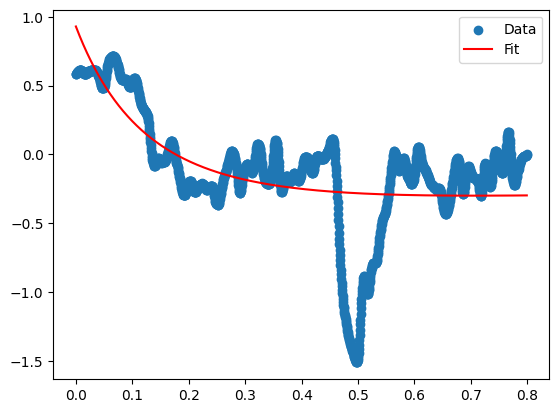

In [ ]:
WWtemp = 0.12
ZZtemp = 0.06

def Bz_function(x, dx, phi, JJ):
    term1 = np.cos(phi * np.pi / 180) * \
    np.log( ( (-WWtemp + x - dx)**2 + ZZtemp**2 ) / ( (WWtemp + x - dx)**2 + ZZtemp**2 ) )
    term2 = -np.sin(phi * np.pi / 180) * np.arctan( (x - dx - WWtemp) /ZZtemp )
    term3 = np.sin(phi * np.pi / 180) * np.arctan( (x - dx + WWtemp) /ZZtemp )
    return 2 * JJ * (term1 + term2 + term3)


profile_index = 70

yset = np.array(yi)[:,profile_index]
bset = np.array(zi)[:,profile_index]-np.array(zi)[-1,profile_index]
print([len(yset),len(bset)])


params, cov = curve_fit(Bz_function, yset, bset, p0 = [-WWtemp, 75, 10], maxfev=10000)
print(params)

plt.scatter(yset, bset, label='Data')
plt.plot(yset, Bz_function(yset, *params), 'r-', label='Fit')
plt.legend()
plt.show()

[1685, 1685]
[ 2.38142557e-01  4.21454232e-02  3.11208242e-01 -7.99676711e+01
  1.73140219e+01]


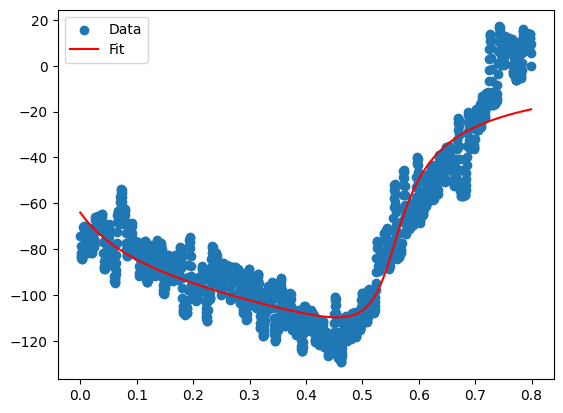

In [ ]:
WWtemp = .5
ZZtemp = 0.01

def Bz_function(x, dx, ZZ, WW, phi, JJ):
    term1 = np.cos(phi * np.pi / 180) * \
    np.log( ( (-WW + x - dx)**2 + ZZ**2 ) / ( (WW + x - dx)**2 + ZZ**2 ) )
    term2 = -np.sin(phi * np.pi / 180) * np.arctan( (x - dx - WW) /ZZ )
    term3 = np.sin(phi * np.pi / 180) * np.arctan( (x - dx + WW) /ZZ )
    return 2 * JJ * (term1 + term2 + term3)


profile_index = 70

yset = np.array(yi)[:,profile_index]
bset = np.array(zi2)[:,profile_index]-np.array(zi2)[-1,profile_index]
print([len(yset),len(bset)])


params, cov = curve_fit(Bz_function, yset, bset, p0 = [-WWtemp, ZZtemp, WWtemp, 75, 10], maxfev=10000)
print(params)

plt.scatter(yset, bset, label='Data')
plt.plot(yset, Bz_function(yset, *params), 'r-', label='Fit')
plt.legend()
plt.show()

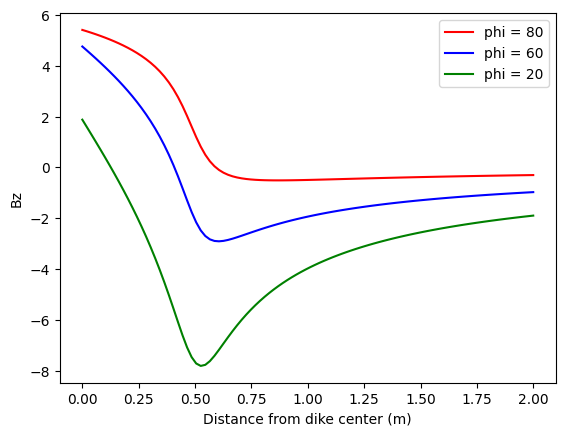

In [ ]:
def Bz_function(x, dx, ZZ, WW, phi, JJ):
    term1 = np.cos(phi * np.pi / 180) * \
    np.log( ( (-WW + x - dx)**2 + ZZ**2 ) / ( (WW + x - dx)**2 + ZZ**2 ) )
    term2 = -np.sin(phi * np.pi / 180) * np.arctan( (x - dx - WW) /ZZ )
    term3 = np.sin(phi * np.pi / 180) * np.arctan( (x - dx + WW) /ZZ )
    return 2 * JJ * (term1 + term2 + term3)

xs = np.linspace(0,2,100)

plt.plot(xs, Bz_function(xs, 0, 0.1, 0.5, 80, 1), 'r-', label='phi = 80')
plt.plot(xs, Bz_function(xs, 0, 0.1, 0.5, 60, 1), 'b-', label='phi = 60')
plt.plot(xs, Bz_function(xs, 0, 0.1, 0.5, 20, 1), 'g-', label='phi = 20')
plt.legend()
plt.xlabel("Distance from dike center (m)")
plt.ylabel("Bz")
plt.show()

In [ ]:
np.linspace(0,3,100)

array([0.        , 0.03030303, 0.06060606, 0.09090909, 0.12121212,
       0.15151515, 0.18181818, 0.21212121, 0.24242424, 0.27272727,
       0.3030303 , 0.33333333, 0.36363636, 0.39393939, 0.42424242,
       0.45454545, 0.48484848, 0.51515152, 0.54545455, 0.57575758,
       0.60606061, 0.63636364, 0.66666667, 0.6969697 , 0.72727273,
       0.75757576, 0.78787879, 0.81818182, 0.84848485, 0.87878788,
       0.90909091, 0.93939394, 0.96969697, 1.        , 1.03030303,
       1.06060606, 1.09090909, 1.12121212, 1.15151515, 1.18181818,
       1.21212121, 1.24242424, 1.27272727, 1.3030303 , 1.33333333,
       1.36363636, 1.39393939, 1.42424242, 1.45454545, 1.48484848,
       1.51515152, 1.54545455, 1.57575758, 1.60606061, 1.63636364,
       1.66666667, 1.6969697 , 1.72727273, 1.75757576, 1.78787879,
       1.81818182, 1.84848485, 1.87878788, 1.90909091, 1.93939394,
       1.96969697, 2.        , 2.03030303, 2.06060606, 2.09090909,
       2.12121212, 2.15151515, 2.18181818, 2.21212121, 2.24242

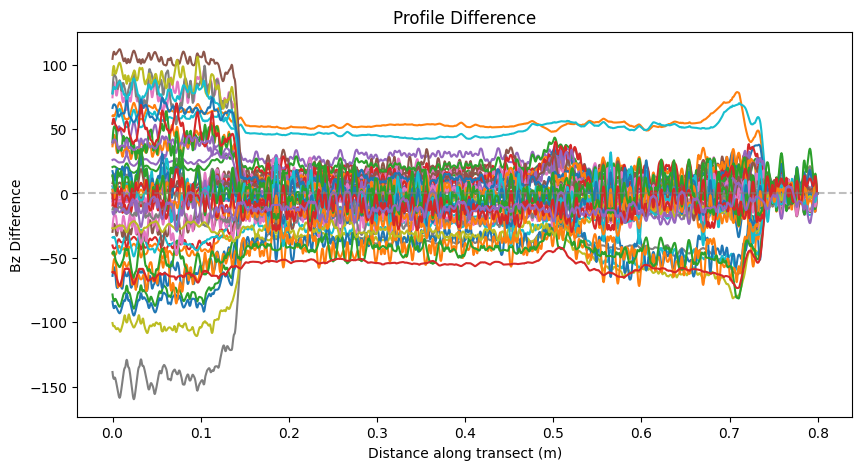

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assume yi and zi are already loaded

# Zero each profile (column) at its end, as before
zi2 = zi.copy()
for col in range(zi2.shape[1]):
    zi2[:, col] = zi2[:, col] - zi2[-1, col]

# Pick which profiles to compare (here: 10 evenly spaced columns, as before)
num_cols = zi.shape[1]
step = num_cols // 10
col_indices = [i*step for i in range(10)]

plt.figure(figsize=(10,5))

# Now, for all ordered pairs (i, j) (i ≠ j), plot the difference
for i in range(len(col_indices)):
    for j in range(i+1, len(col_indices)):
        col_i = col_indices[i]
        col_j = col_indices[j]
        # Always use the same x-vector for both
        y = yi[:, col_i]   # Should be identical for all profiles if regular grid
        prof_i = zi2[:, col_i]
        prof_j = zi2[:, col_j]
        diff = prof_i - prof_j


        plt.plot(y, diff, label=f'Zeroed Col {col_i} - Zeroed Col {col_j}')



plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Distance along transect (m)")
plt.ylabel(f'Bz Difference')
plt.title(f'Profile Difference')
#plt.legend()
plt.show()

        # (Optional) if you want a single big plot of all pairs overlaid, collect all diffs/labels and plot after loop

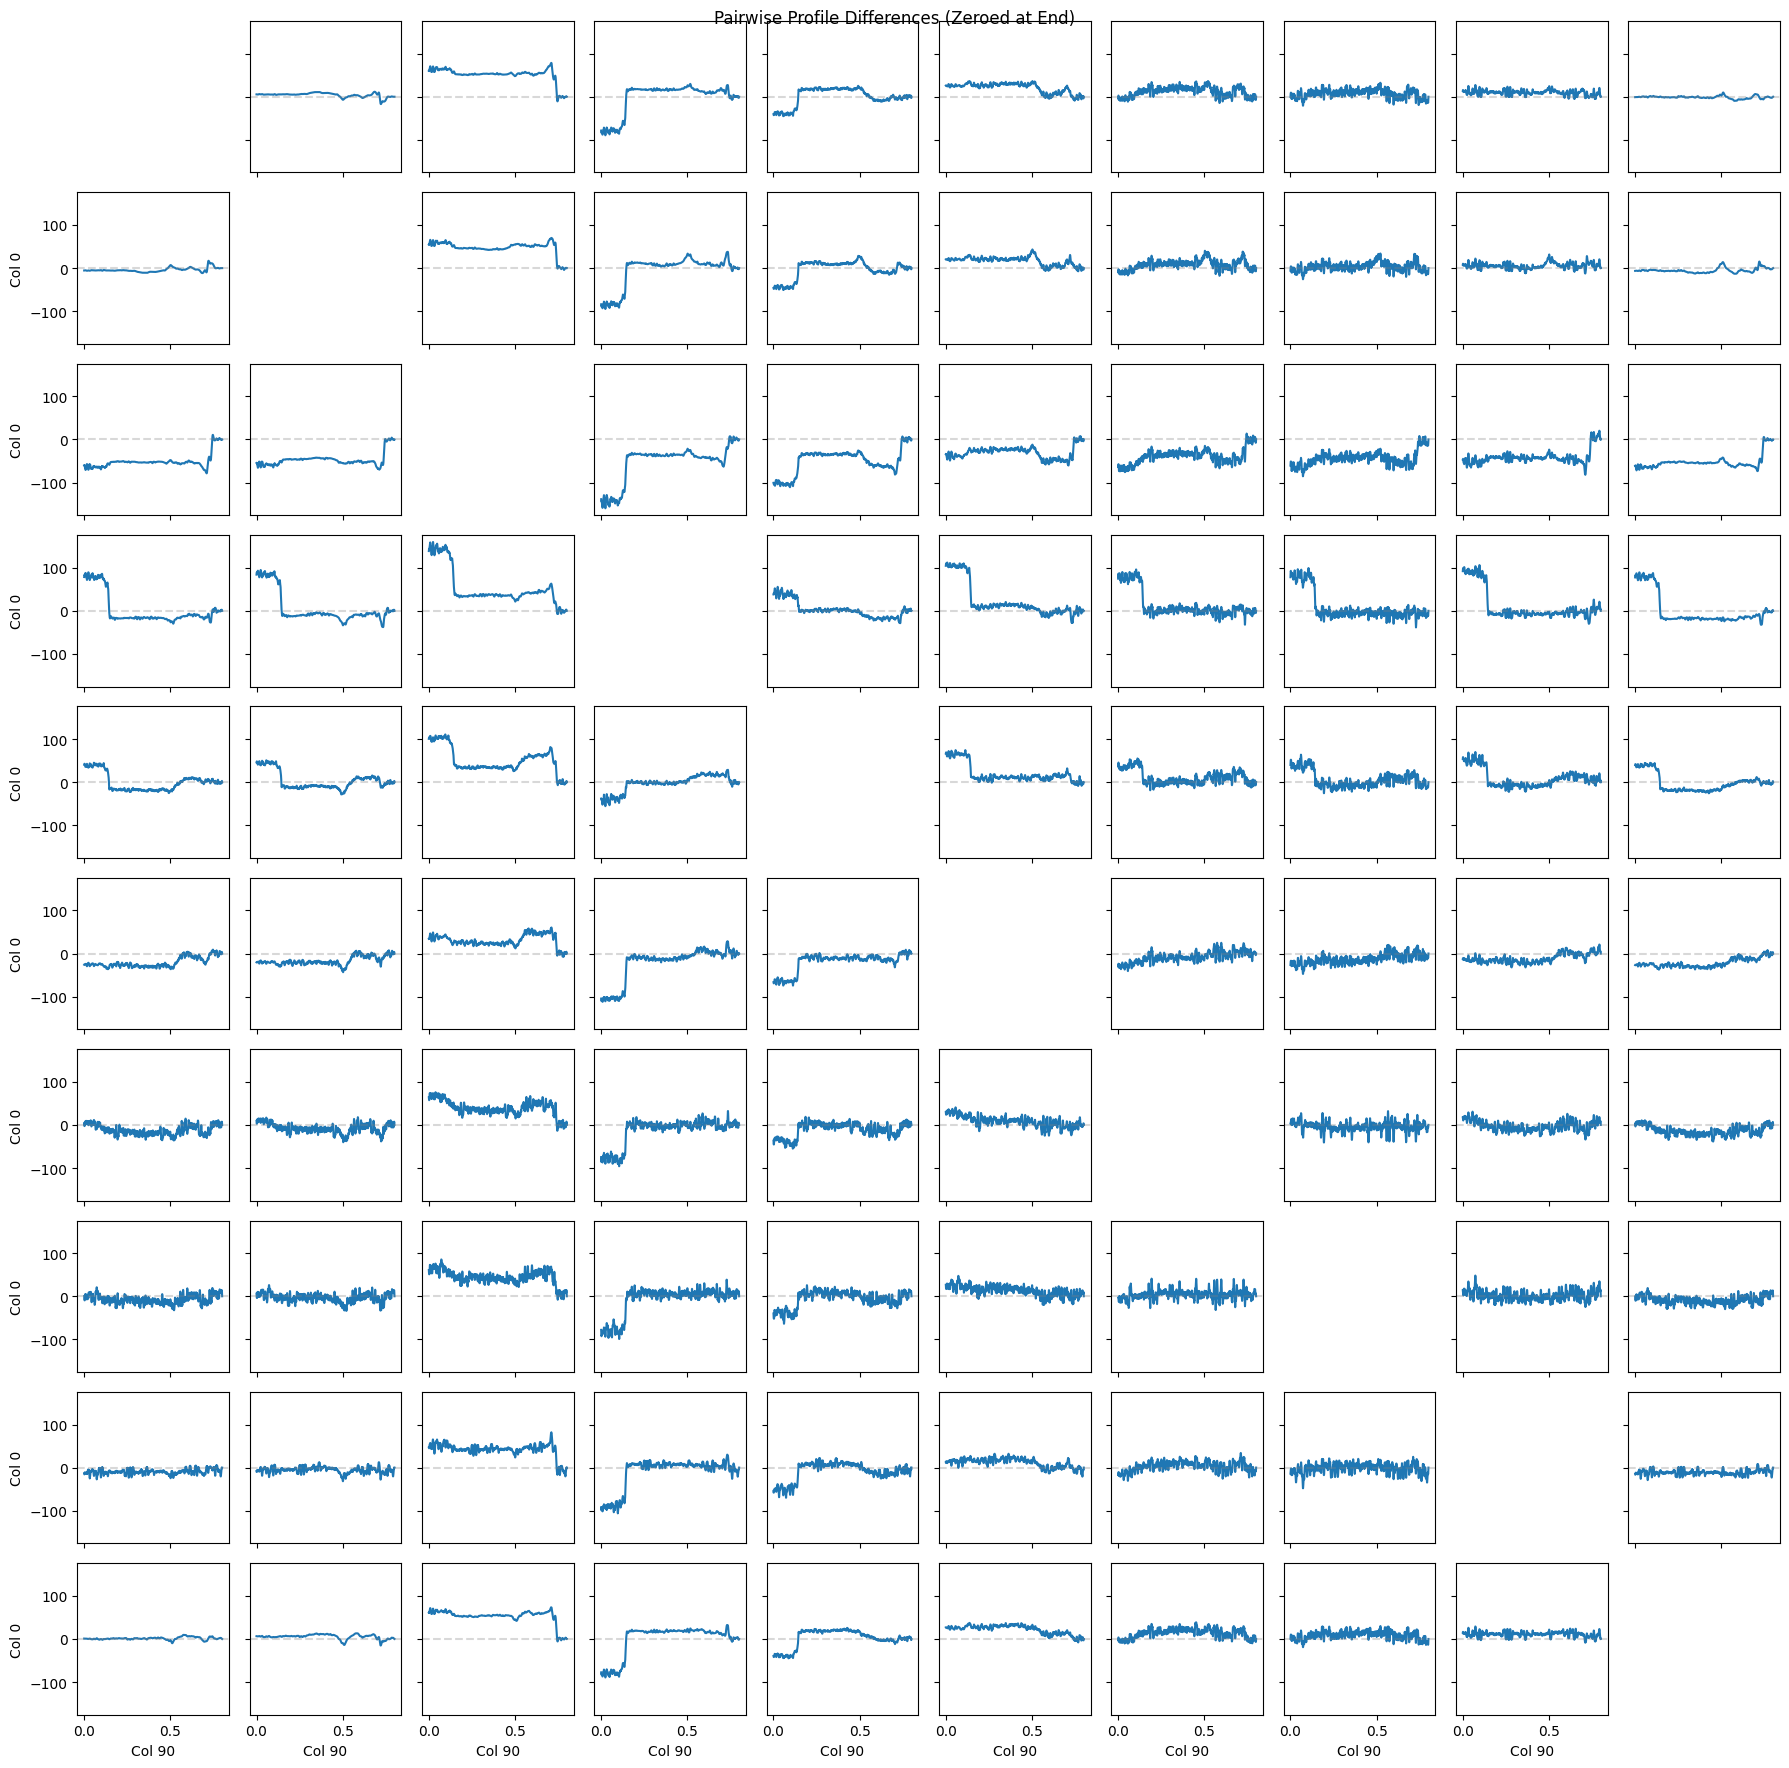

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(col_indices), len(col_indices), figsize=(18,18), sharex=True, sharey=True)

for i, col_i in enumerate(col_indices):
    for j, col_j in enumerate(col_indices):
        if i == j:
            axs[i,j].axis('off')  # No need to compare profile to itself
            continue
        y = yi[:, col_i]
        prof_i = zi2[:, col_i]
        prof_j = zi2[:, col_j]
        axs[i,j].plot(y, prof_i - prof_j)
        axs[i,j].axhline(0, color='gray', linestyle='--', alpha=0.3)
        if i == len(col_indices)-1:
            axs[i,j].set_xlabel(f'Col {col_i}')
        if j == 0:
            axs[i,j].set_ylabel(f'Col {col_j}')

plt.suptitle("Pairwise Profile Differences (Zeroed at End)")
plt.tight_layout()
plt.show()

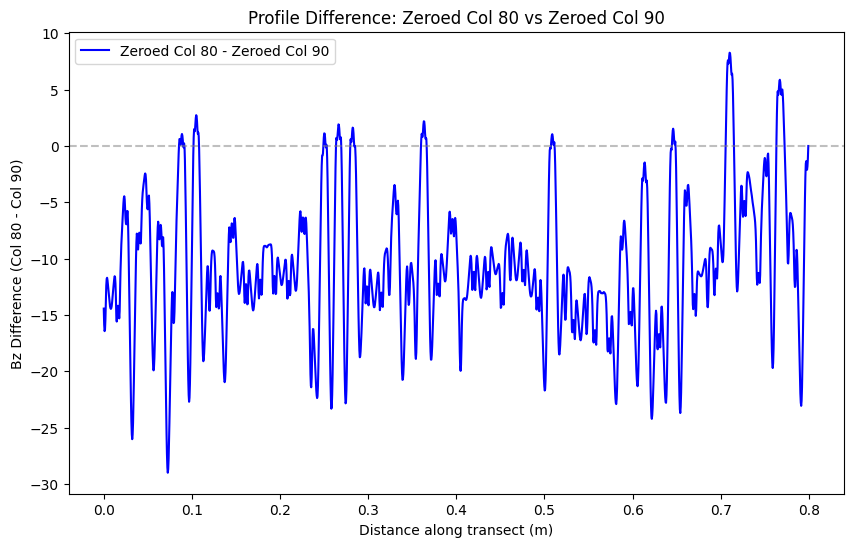

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assume zi and yi are defined

# Zero each column at its end, as before
zi2 = zi.copy()
for col in range(zi2.shape[1]):
    zi2[:, col] = zi2[:, col] - zi2[-1, col]

col_i = 80
col_j = 90

y = yi[:, col_i]    # or yi[:, col_j], they should be identical if on a grid

# The normalized (zeroed) profiles
prof_i = zi2[:, col_i]
prof_j = zi2[:, col_j]

# Their difference
diff = prof_i - prof_j

plt.figure(figsize=(10,6))
plt.plot(y, diff, 'b-', label=f'Zeroed Col {col_i} - Zeroed Col {col_j}')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Distance along transect (m)")
plt.ylabel(f'Bz Difference (Col {col_i} - Col {col_j})')
plt.title(f'Profile Difference: Zeroed Col {col_i} vs Zeroed Col {col_j}')
plt.legend()
plt.show()